# Causal Growth Engine
Experiment design, variance reduction, and policy learning on the Hillstrom e-mail RCT **Data.** Kevin Hillstrom's *MineThatData* e-mail challenge: 64,000 customers randomised into `Mens E-Mail`, `Womens E-Mail`, or `No E-Mail`, with pre-treatment covariates and 2-week post-treatment outcomes (`visit`, `conversion`, `spend`).

---

In [1]:

%pip install -q duckdb

import numpy as np
import pandas as pd
import duckdb
import scipy.stats as st
import statsmodels.api as sm
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import HistGradientBoostingRegressor

SEED = 42
rng = np.random.default_rng(SEED)

pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
plt.rcParams.update({
    "figure.figsize": (8, 4.5), "figure.dpi": 110, "axes.grid": True,
    "grid.alpha": 0.25, "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 10, "axes.titlesize": 11, "axes.titleweight": "bold",
})

print("Environment ready | duckdb", duckdb.__version__)

Environment ready | duckdb 1.3.2


## 1. Experiment design document

Written as if *before* the data arrived. Everything downstream is pre-registered here, which is what makes
the subgroup analysis in §7 confirmatory rather than a fishing expedition.

**Hypothesis.** A targeted promotional e-mail increases 2-week revenue per customer relative to no e-mail.

**Unit of randomisation.** Customer. No interference expected between customers (no referral/social mechanic
in this campaign), so SUTVA is plausible — see §12 for where this would break.

**Arms.** `No E-Mail` (control), `Mens E-Mail`, `Womens E-Mail`, allocated 1:1:1.

**Metric hierarchy.**

| Tier | Metric | Role |
|---|---|---|
| Primary (OEC) | `spend` — revenue per customer, 2 weeks | The decision metric |
| Secondary | `visit`, `conversion` | Mechanism: does the lift come from traffic or from basket size? |
| Guardrail | `visit` in the wrong-gender arm | Detects annoyance / mis-targeting |

**Decision rule.** Ship a blanket campaign only if the primary metric's lower confidence bound exceeds the
per-e-mail cost. Otherwise, evaluate a *targeted* policy (§10).

**Pre-registered subgroups.** `mens` / `womens` purchase history, `newbie`, `channel`. These are stated
in advance precisely so the interaction tests in §7 carry inferential weight; anything discovered by the
CATE model in §8 is explicitly exploratory and is treated as hypothesis-generating.

**Analysis plan.** Welch t-test on the primary metric; Lin-adjusted OLS with HC3 errors as the main
specification; CUPED/CUPAC for variance reduction; Holm–Bonferroni across the arm × metric family.

## 2. Ingestion — warehouse-style SQL

The transformation is written in SQL against DuckDB rather than in pandas, because in production this
logic lives in the warehouse (Snowflake / BigQuery) as a dbt model, not in a notebook. DuckDB runs the
same ANSI SQL locally.

Note the explicit split into **pre-treatment covariates** and **post-treatment outcomes**. Keeping these
in separate blocks is not cosmetic: it is the guard against the single most common error in causal work,
which is conditioning on something the treatment could have affected.

In [2]:
URL = ("http://www.minethatdata.com/"
       "Kevin_Hillstrom_MineThatData_E-MailAnalytics_DataMiningChallenge_2008.03.20.csv")

raw = pd.read_csv(URL)
con = duckdb.connect()
con.register("raw", raw)

df = con.execute("""
    SELECT
        -- ---------- PRE-treatment covariates (safe to condition on) ----------
        recency                              AS recency_months,
        history                              AS pre_spend_12m,
        ln(1 + history)                       AS log_pre_spend_12m,
        mens                                 AS hist_bought_mens,
        womens                               AS hist_bought_womens,
        newbie                               AS is_new_customer,
        zip_code                             AS zip_class,
        channel                              AS acq_channel,

        -- ---------- Randomised assignment ----------
        segment                              AS arm,
        CASE segment WHEN 'No E-Mail' THEN 0 ELSE 1 END AS treated_any,

        -- ---------- POST-treatment outcomes (never a feature) ----------
        spend                                AS y_spend,
        visit                                AS y_visit,
        conversion                           AS y_conversion
    FROM raw
""").df()

# history_segment is a coarse binning of `history` -> collinear, dropped.
CATS = ["zip_class", "acq_channel"]
NUMS = ["recency_months", "log_pre_spend_12m", "hist_bought_mens",
        "hist_bought_womens", "is_new_customer"]

X_df = pd.get_dummies(df[NUMS + CATS], columns=CATS, drop_first=True).astype(float)
FEATURES = list(X_df.columns)
X = X_df.to_numpy()

print(f"{len(df):,} customers | {len(FEATURES)} covariates")
display(df.groupby("arm").agg(
    n=("y_spend", "size"), spend=("y_spend", "mean"),
    visit_rate=("y_visit", "mean"), conv_rate=("y_conversion", "mean")))

64,000 customers | 9 covariates


,n,spend,visit_rate,conv_rate
arm,,,,
Mens E-Mail,21307,1.4226,0.1828,0.0125
No E-Mail,21306,0.6528,0.1062,0.0057
Womens E-Mail,21387,1.0772,0.1514,0.0088


## 3. Is the randomisation real?

Two checks, in order. Both must pass before any effect estimate is credible.

**3a. Sample Ratio Mismatch (SRM).** Arm sizes should match the intended 1:1:1 split. A failed SRM is
usually a bug in the assignment or logging layer (bot filtering applied asymmetrically, a redirect that
drops one arm, a delayed-assignment race) — and it invalidates every downstream number, because the
mechanism that broke the ratio has almost certainly broken exchangeability too. Industry convention is to
treat p < 0.001 as a hard stop.

**3b. Covariate balance.** Standardised mean differences on *pre-treatment* covariates. Under
randomisation these should hover around zero; |SMD| > 0.10 is the usual flag. This is an assumption check,
not a hypothesis test, which is why SMD is reported rather than a p-value per covariate — with n = 64,000
a trivially small imbalance would be "significant" and tell you nothing.

In [3]:
# 3a. SRM
counts = df["arm"].value_counts().sort_index()
expected = np.full(len(counts), len(df) / len(counts))
chi2, p_srm = st.chisquare(counts.values, expected)

print("Sample Ratio Mismatch check")
print(f"  observed : {dict(counts)}")
print(f"  expected : {expected[0]:,.0f} per arm")
print(f"  chi2 = {chi2:.3f}, p = {p_srm:.4f}")
print(f"  -> {'PASS' if p_srm > 0.001 else 'FAIL — STOP, do not analyse'}")

Sample Ratio Mismatch check
  observed : {'Mens E-Mail': np.int64(21307), 'No E-Mail': np.int64(21306), 'Womens E-Mail': np.int64(21387)}
  expected : 21,333 per arm
  chi2 = 0.203, p = 0.9037
  -> PASS


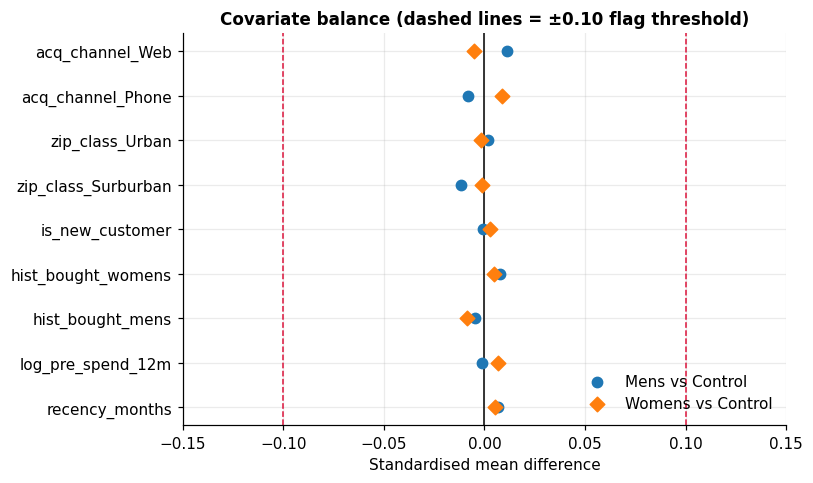

Max |SMD| = 0.0117 -> balanced


In [4]:
# 3b. Covariate balance (standardised mean differences vs control
def smd(a, b):
    """Standardised mean difference; pooled SD denominator."""
    sd = np.sqrt((a.var(ddof=1) + b.var(ddof=1)) / 2)
    return 0.0 if sd == 0 else (a.mean() - b.mean()) / sd

ctrl_mask = df["arm"].eq("No E-Mail").to_numpy()
bal = pd.DataFrame({
    arm: {f: smd(X[df["arm"].eq(arm).to_numpy(), j], X[ctrl_mask, j])
          for j, f in enumerate(FEATURES)}
    for arm in ["Mens E-Mail", "Womens E-Mail"]
})

fig, ax = plt.subplots(figsize=(7.5, 4.5))
y = np.arange(len(bal))
ax.scatter(bal["Mens E-Mail"], y, label="Mens vs Control", s=45, zorder=3)
ax.scatter(bal["Womens E-Mail"], y, label="Womens vs Control", s=45, marker="D", zorder=3)
ax.axvline(0, color="black", lw=1)
for t in (-0.10, 0.10):
    ax.axvline(t, color="crimson", ls="--", lw=1)
ax.set_yticks(y); ax.set_yticklabels(bal.index)
ax.set_xlim(-0.15, 0.15)
ax.set_xlabel("Standardised mean difference")
ax.set_title("Covariate balance (dashed lines = ±0.10 flag threshold)")
ax.legend(loc="lower right", frameon=False)
plt.tight_layout(); plt.show()

print(f"Max |SMD| = {bal.abs().to_numpy().max():.4f} -> "
      f"{'balanced' if bal.abs().to_numpy().max() < 0.10 else 'IMBALANCE, investigate'}")

## 4. What could this experiment actually detect?

Two things that are routinely confused:

**Post-hoc power is not a diagnostic.** Computing power at the *observed* effect size is a monotone
transform of the p-value (Hoenig & Heisey, 2001) — it adds no information and is never reported here.

**Achieved MDE is a diagnostic.** Given the realised control-arm variance and the actual arm sizes, what
is the smallest true effect this experiment had an 80% chance of detecting? A null result is only
informative if the MDE sits below the effect size that would matter commercially.

$$\text{MDE} = (z_{1-\alpha/2} + z_{1-\beta})\,\sigma\sqrt{\tfrac{1}{n_1}+\tfrac{1}{n_0}}$$

A design-stage sensitivity grid is included too, since at planning time σ is a guess, not a measurement.

In [5]:
ALPHA, POWER = 0.05, 0.80
Z = st.norm.ppf(1 - ALPHA / 2) + st.norm.ppf(POWER)

sigma_ctrl = df.loc[ctrl_mask, "y_spend"].std(ddof=1)
n_ctrl = int(ctrl_mask.sum())

print(f"Control-arm SD of spend : ${sigma_ctrl:,.2f}")
print(f"Control-arm mean spend  : ${df.loc[ctrl_mask,'y_spend'].mean():,.4f}")
print(f"Share of zero-spend rows: {(df['y_spend'] == 0).mean():.2%}\n")

print("Achieved MDE (80% power, alpha=0.05), per contrast")
for arm in ["Mens E-Mail", "Womens E-Mail"]:
    n_t = int(df["arm"].eq(arm).sum())
    mde = Z * sigma_ctrl * np.sqrt(1 / n_t + 1 / n_ctrl)
    print(f"  {arm:<14} n_t={n_t:,}  MDE = ${mde:,.4f} per customer")

n_t = int((~ctrl_mask).sum())
mde_pooled = Z * sigma_ctrl * np.sqrt(1 / n_t + 1 / n_ctrl)
print(f"  {'Any e-mail':<14} n_t={n_t:,}  MDE = ${mde_pooled:,.4f} per customer")

Control-arm SD of spend : $11.59
Control-arm mean spend  : $0.6528
Share of zero-spend rows: 99.10%

Achieved MDE (80% power, alpha=0.05), per contrast
  Mens E-Mail    n_t=21,307  MDE = $0.3145 per customer
  Womens E-Mail  n_t=21,387  MDE = $0.3142 per customer
  Any e-mail     n_t=42,694  MDE = $0.2723 per customer


Required n PER ARM (equal allocation)


,sigma=$9,sigma=$12,sigma=$14
MDE = $0.25,"18,972","33,728","52,700"
MDE = $0.50,"4,743","8,432","13,175"
MDE = $0.75,"2,108","3,748","5,856"
MDE = $1.00,"1,186","2,108","3,294"
MDE = $1.50,527,937,"1,464"


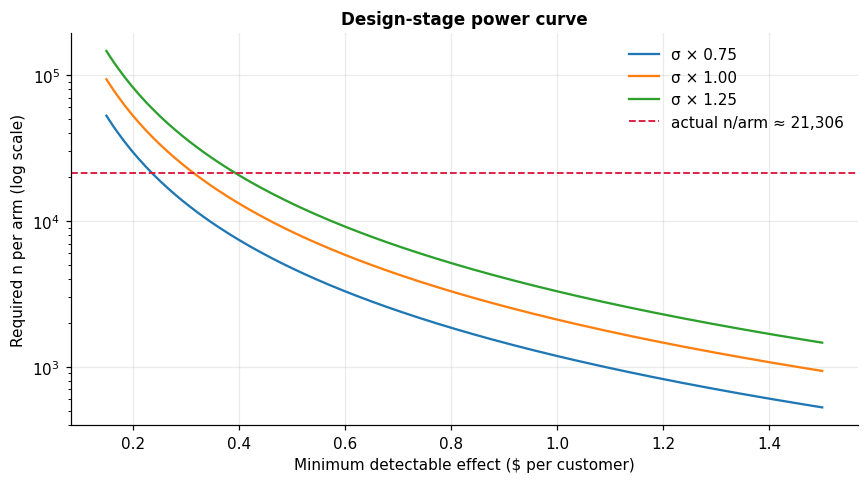

In [6]:
# Design-stage sensitivity: required n per arm across plausible (sigma, MDE) pairs.
mdes = np.array([0.25, 0.50, 0.75, 1.00, 1.50])
sigmas = np.array([0.75, 1.0, 1.25]) * sigma_ctrl
grid = pd.DataFrame(
    {f"sigma=${s:,.0f}": [int(np.ceil(2 * (Z * s / m) ** 2)) for m in mdes] for s in sigmas},
    index=[f"MDE = ${m:.2f}" for m in mdes])
print("Required n PER ARM (equal allocation)")
display(grid.map(lambda v: f"{v:,}"))

fig, ax = plt.subplots()
mde_range = np.linspace(0.15, 1.5, 200)
for s, lbl in zip(sigmas, ["σ × 0.75", "σ × 1.00", "σ × 1.25"]):
    ax.plot(mde_range, 2 * (Z * s / mde_range) ** 2, label=lbl)
ax.axhline(n_ctrl, color="crimson", ls="--", lw=1.2, label=f"actual n/arm ≈ {n_ctrl:,}")
ax.set_yscale("log"); ax.set_xlabel("Minimum detectable effect ($ per customer)")
ax.set_ylabel("Required n per arm (log scale)")
ax.set_title("Design-stage power curve")
ax.legend(frameon=False)
plt.tight_layout(); plt.show()

## 5. Average treatment effect

`spend` is ~99% zeros with a long right tail, so the sample mean is heavily skewed. Three points:

1. Welch's t-test is still valid here — the CLT applies to the *sampling distribution of the mean* at
   n ≈ 21,000 per arm, not to the raw outcome. Welch (unequal variance) rather than Student, because the
   treatment plausibly changes the variance as well as the mean.
2. It is nonetheless verified against a stratified **bootstrap**, which makes no distributional assumption.
3. The main specification is **Lin's estimator**: OLS of the outcome on treatment, centred covariates, and
   their interaction, with HC3 robust errors. Under randomisation this is consistent regardless of whether
   the outcome model is right, and it is guaranteed not to *hurt* asymptotic precision relative to a plain
   difference in means — unlike naive covariate adjustment without interactions, which can.

In [7]:
def diff_in_means(y, t):
    """Welch difference in means -> (effect, se, ci_lo, ci_hi, p)."""
    y1, y0 = y[t == 1], y[t == 0]
    n1, n0 = len(y1), len(y0)
    v1, v0 = y1.var(ddof=1), y0.var(ddof=1)
    eff = y1.mean() - y0.mean()
    se = np.sqrt(v1 / n1 + v0 / n0)
    if se == 0:                      # degenerate slice (can happen in tiny subgroups)
        return eff, 0.0, eff, eff, np.nan
    denom = (v1 / n1) ** 2 / (n1 - 1) + (v0 / n0) ** 2 / (n0 - 1)
    dof = (v1 / n1 + v0 / n0) ** 2 / denom
    tcrit = st.t.ppf(0.975, dof)
    p = 2 * st.t.sf(abs(eff / se), dof)
    return eff, se, eff - tcrit * se, eff + tcrit * se, p


def holm(pvals):
    """Holm-Bonferroni step-down adjusted p-values."""
    p = np.asarray(pvals, float); m = len(p); order = np.argsort(p)
    adj = np.empty(m); running = 0.0
    for i, idx in enumerate(order):
        running = max(running, (m - i) * p[idx])
        adj[idx] = min(running, 1.0)
    return adj


rows = []
for arm in ["Mens E-Mail", "Womens E-Mail"]:
    sub = df[df["arm"].isin([arm, "No E-Mail"])]
    t = sub["arm"].eq(arm).to_numpy().astype(int)
    for metric, label in [("y_spend", "spend ($)"), ("y_visit", "visit rate"),
                          ("y_conversion", "conversion rate")]:
        eff, se, lo, hi, p = diff_in_means(sub[metric].to_numpy(float), t)
        base = sub.loc[sub["arm"].eq("No E-Mail"), metric].mean()
        rows.append(dict(arm=arm.replace(" E-Mail", ""), metric=label, control=base,
                         effect=eff, se=se, ci_lo=lo, ci_hi=hi, p_raw=p,
                         rel_lift=eff / base if base else np.nan))

ate = pd.DataFrame(rows)
ate["p_holm"] = holm(ate["p_raw"])
ate["sig"] = np.where(ate["p_holm"] < 0.05, "**", "")
display(ate[["arm", "metric", "control", "effect", "ci_lo", "ci_hi",
             "rel_lift", "p_raw", "p_holm", "sig"]])

,arm,metric,control,effect,ci_lo,ci_hi,rel_lift,p_raw,p_holm,sig
0,Mens,spend ($),0.6528,0.7698,0.4851,1.0545,1.1793,0.0000,0.0000,**
1,Mens,visit rate,0.1062,0.0766,0.0700,0.0832,0.7214,0.0000,0.0000,**
2,Mens,conversion rate,0.0057,0.0068,0.0050,0.0086,1.1884,0.0000,0.0000,**
3,Womens,spend ($),0.6528,0.4244,0.1690,0.6799,0.6502,0.0011,0.0011,**
4,Womens,visit rate,0.1062,0.0452,0.0389,0.0516,0.4261,0.0000,0.0000,**
5,Womens,conversion rate,0.0057,0.0031,0.0015,0.0047,0.5433,0.0002,0.0003,**


In [8]:
# Bootstrap sanity check on the primary metric, pooled treatment (any e-mail vs none).
y_all = df["y_spend"].to_numpy(float)
t_all = df["treated_any"].to_numpy()
idx_t, idx_c = np.flatnonzero(t_all == 1), np.flatnonzero(t_all == 0)

B = 2000
boot = np.empty(B)
for b in range(B):
    bt = rng.choice(idx_t, len(idx_t), replace=True)
    bc = rng.choice(idx_c, len(idx_c), replace=True)
    boot[b] = y_all[bt].mean() - y_all[bc].mean()

eff, se, lo, hi, p = diff_in_means(y_all, t_all)
print("Primary metric — any e-mail vs no e-mail")
print(f"  Welch     : ATE = ${eff:.4f}  95% CI [{lo:.4f}, {hi:.4f}]  p = {p:.3e}")
print(f"  Bootstrap : ATE = ${boot.mean():.4f}  95% CI "
      f"[{np.percentile(boot, 2.5):.4f}, {np.percentile(boot, 97.5):.4f}]")
print(f"  Bootstrap skewness of the mean = {st.skew(boot):.3f} (≈0 -> normal approx is fine)")

Primary metric — any e-mail vs no e-mail
  Welch     : ATE = $0.5968  95% CI [0.3762, 0.8174]  p = 1.148e-07
  Bootstrap : ATE = $0.5967  95% CI [0.3724, 0.8103]
  Bootstrap skewness of the mean = -0.086 (≈0 -> normal approx is fine)


In [9]:
# Lin's estimator: Y ~ T + (X - X_bar) + T:(X - X_bar), HC3 errors.
def lin_estimator(y, t, X):
    Xc = X - X.mean(axis=0, keepdims=True)
    D = np.column_stack([np.ones(len(y)), t, Xc, t[:, None] * Xc])
    fit = sm.OLS(y, D).fit(cov_type="HC3")
    return fit.params[1], fit.bse[1], fit.conf_int()[1]

eff_lin, se_lin, ci_lin = lin_estimator(y_all, t_all, X)
print(f"Lin-adjusted ATE = ${eff_lin:.4f}  SE {se_lin:.4f}  "
      f"95% CI [{ci_lin[0]:.4f}, {ci_lin[1]:.4f}]")

Lin-adjusted ATE = $0.5978  SE 0.1125  95% CI [0.3774, 0.8183]


### 5b. Where does the lift come from?

Revenue per customer decomposes as *conversion rate × average order value among converters*. The
conversion-rate piece is causal (conversion is measured on everyone, and assignment is random). The AOV
piece is **not**: conditioning on having converted conditions on a post-treatment variable, so the
comparison is between two differently-selected groups of customers. It is reported as a descriptive
mechanism clue with that caveat attached, never as an effect.

In [10]:
conv = df.loc[df["y_conversion"] == 1]
mech = pd.DataFrame({
    "conversion_rate": df.groupby("treated_any")["y_conversion"].mean(),
    "aov_among_converters": conv.groupby("treated_any")["y_spend"].mean(),
    "n_converters": df.groupby("treated_any")["y_conversion"].sum(),
})
mech.index = ["No e-mail", "Any e-mail"]
display(mech)

d_conv = mech.loc["Any e-mail", "conversion_rate"] - mech.loc["No e-mail", "conversion_rate"]
aov_c = mech.loc["No e-mail", "aov_among_converters"]
print(f"Conversion-rate effect  : {d_conv:+.4%}  (causal)")
print(f"  -> at control AOV that alone explains ${d_conv * aov_c:.4f} of the "
      f"${eff:.4f} total ATE ({d_conv * aov_c / eff:.0%})")
print("AOV gap among converters: "
      f"${mech.loc['Any e-mail','aov_among_converters'] - aov_c:+.2f}  (NOT causal — selection)")

,conversion_rate,aov_among_converters,n_converters
No e-mail,0.0057,114.0027,122
Any e-mail,0.0107,116.9952,456


Conversion-rate effect  : +0.4955%  (causal)
  -> at control AOV that alone explains $0.5648 of the $0.5968 total ATE (95%)
AOV gap among converters: $+2.99  (NOT causal — selection)


## 6. Variance reduction

The MDE in §4 is set by the control-arm variance. Any variance we can explain with *pre-treatment*
information shrinks the confidence interval without touching the point estimate — equivalent to having
run a larger experiment, for free.

**CUPED** (Deng et al., 2013) uses one pre-period covariate:

$$Y^{cuped}_i = Y_i - \theta\,(X_i - \bar X), \qquad \theta = \frac{\mathrm{Cov}(Y, X)}{\mathrm{Var}(X)}$$

θ is estimated **on the control arm only**. Estimating it on pooled data uses post-treatment outcomes to
build the adjustment, which introduces a small bias in the effect estimate — a subtle and common bug.

**CUPAC** (the DoorDash generalisation) replaces the single covariate with an ML prediction
$\hat m(X)$ built from *all* pre-treatment covariates, fitted on control-arm outcomes and **cross-fitted**
so that no observation contributes to its own prediction. Variance reduction is governed by
$\rho^2 = \mathrm{Corr}(Y, C)^2$, giving an effective sample-size multiplier of $1/(1-\rho^2)$.

The honest expectation for this dataset: pre-period spend correlates weakly with 2-week post spend, so
CUPED alone will do very little. That result is reported as-is rather than hidden — knowing *when* a
technique will not help is the point.

,estimator,ate,se,ci_lo,ci_hi,rho2,var_reduction,ess_multiplier
0,Difference in means,0.5968,0.1126,0.3762,0.8174,0.0000,0.0000,1.0000
1,"CUPED (pre-period spend, θ=0.0007)",0.5956,0.1125,0.3750,0.8162,0.0002,0.0003,1.0002
2,"CUPAC (cross-fitted ML, θ=0.5630)",0.5943,0.1125,0.3737,0.8149,0.0003,0.0004,1.0003
3,"Lin (OLS + interactions, HC3)",0.5978,0.1125,0.3774,0.8183,NaN,0.0017,NaN


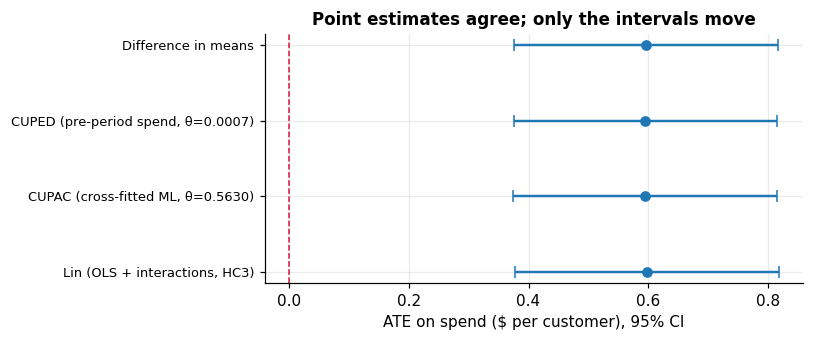

In [11]:
def cuped_transform(y, t, c):
    """Theta estimated on control arm only."""
    theta = np.cov(y[t == 0], c[t == 0])[0, 1] / np.var(c[t == 0], ddof=1)
    return y - theta * (c - c.mean()), theta


def crossfit_control_predictor(X, t, y, n_splits=5, seed=SEED):
    """Out-of-fold E[Y | X, control] for every row (CUPAC covariate)."""
    oof = np.zeros(len(y))
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    for tr, te in skf.split(X, t):
        ctl = tr[t[tr] == 0]
        m = HistGradientBoostingRegressor(
            max_iter=300, learning_rate=0.05, max_depth=4,
            min_samples_leaf=50, random_state=seed).fit(X[ctl], y[ctl])
        oof[te] = m.predict(X[te])
    return oof


c_cuped = df["pre_spend_12m"].to_numpy(float)
c_cupac = crossfit_control_predictor(X, t_all, y_all)

y_cuped, theta_cuped = cuped_transform(y_all, t_all, c_cuped)
y_cupac, theta_cupac = cuped_transform(y_all, t_all, c_cupac)

def summarise(name, y, t, extra=None):
    e, s, lo, hi, p = diff_in_means(y, t)
    rho2 = 0.0 if extra is None else np.corrcoef(y_all[t == 0], extra[t == 0])[0, 1] ** 2
    return dict(estimator=name, ate=e, se=s, ci_lo=lo, ci_hi=hi,
                ci_width=hi - lo, rho2=rho2, ess_multiplier=1 / (1 - rho2) if rho2 < 1 else np.nan)

vr = pd.DataFrame([
    summarise("Difference in means", y_all, t_all),
    summarise(f"CUPED (pre-period spend, θ={theta_cuped:.4f})", y_cuped, t_all, c_cuped),
    summarise(f"CUPAC (cross-fitted ML, θ={theta_cupac:.4f})", y_cupac, t_all, c_cupac),
])
vr.loc[len(vr)] = dict(estimator="Lin (OLS + interactions, HC3)", ate=eff_lin, se=se_lin,
                       ci_lo=ci_lin[0], ci_hi=ci_lin[1], ci_width=ci_lin[1] - ci_lin[0],
                       rho2=np.nan, ess_multiplier=np.nan)
vr["se_vs_baseline"] = vr["se"] / vr.loc[0, "se"]
vr["var_reduction"] = 1 - vr["se_vs_baseline"] ** 2
display(vr[["estimator", "ate", "se", "ci_lo", "ci_hi", "rho2",
            "var_reduction", "ess_multiplier"]])

fig, ax = plt.subplots(figsize=(7.5, 3.2))
ypos = np.arange(len(vr))[::-1]
ax.errorbar(vr["ate"], ypos, xerr=1.96 * vr["se"], fmt="o", capsize=4, lw=1.6, ms=6)
ax.axvline(0, color="crimson", ls="--", lw=1)
ax.set_yticks(ypos); ax.set_yticklabels(vr["estimator"], fontsize=8.5)
ax.set_xlabel("ATE on spend ($ per customer), 95% CI")
ax.set_title("Point estimates agree; only the intervals move")
plt.tight_layout(); plt.show()

## 7. Pre-registered subgroups (confirmatory)

These four splits were fixed in §1. The test is an **interaction** — treatment × subgroup — not a pair of
separate significance tests, because "significant in group A, not in group B" is not evidence of a
difference between A and B. p-values are Holm-adjusted across the subgroup family.

In [12]:
sub_rows = []
for var, label in [("hist_bought_womens", "prior womens purchase"),
                   ("hist_bought_mens", "prior mens purchase"),
                   ("is_new_customer", "new customer"),
                   ("acq_channel", "acquisition channel")]:
    grp = df[var]
    levels = sorted(grp.unique())
    if len(levels) == 2:
        g = grp.eq(levels[1]).to_numpy().astype(float)
        D = np.column_stack([np.ones(len(df)), t_all, g, t_all * g])
        fit = sm.OLS(y_all, D).fit(cov_type="HC3")
        sub_rows.append(dict(subgroup=label, contrast=f"{levels[1]} vs {levels[0]}",
                             effect_base=fit.params[1], interaction=fit.params[3],
                             se=fit.bse[3], p_raw=fit.pvalues[3]))
    else:
        d = pd.get_dummies(grp, drop_first=True).astype(float).to_numpy()
        D = np.column_stack([np.ones(len(df)), t_all, d, t_all[:, None] * d])
        fit = sm.OLS(y_all, D).fit(cov_type="HC3")
        k = d.shape[1]
        R = np.zeros((k, D.shape[1])); R[np.arange(k), -k + np.arange(k)] = 1
        w = fit.wald_test(R, scalar=True)
        sub_rows.append(dict(subgroup=label, contrast="joint F-test on all levels",
                             effect_base=fit.params[1], interaction=np.nan,
                             se=np.nan, p_raw=float(w.pvalue)))

subs = pd.DataFrame(sub_rows)
subs["p_holm"] = holm(subs["p_raw"])
display(subs)
sig = subs[subs["p_holm"] < 0.05]
if len(sig):
    print("Interactions surviving Holm:", ", ".join(sig["subgroup"]))
    print("-> the treatment effect genuinely differs across these pre-registered splits.")
else:
    print("No pre-registered interaction survives Holm correction.")
    print("-> no evidence that the effect differs across these splits. Note this is an")
    print("   absence of evidence, not evidence of absence: see the heterogeneity power")
    print("   calculation in section 9d for how much data would be needed.")

,subgroup,contrast,effect_base,interaction,se,p_raw,p_holm
0,prior womens purchase,1 vs 0,0.4799,0.2127,0.2282,0.3513,0.7025
1,prior mens purchase,1 vs 0,0.6237,-0.0472,0.2196,0.8298,0.8298
2,new customer,1 vs 0,0.3459,0.4998,0.2253,0.0265,0.1061
3,acquisition channel,joint F-test on all levels,1.1833,NaN,NaN,0.1020,0.3060


No pre-registered interaction survives Holm correction.
-> no evidence that the effect differs across these splits. Note this is an
   absence of evidence, not evidence of absence: see the heterogeneity power
   calculation in section 9d for how much data would be needed.


## 8. Heterogeneous treatment effects

The ATE answers "should we send this to everyone?" The CATE, $\tau(x) = E[Y(1) - Y(0) \mid X = x]$,
answers "who should we send it to?" — which is the question with the money attached.

**Protocol.** The single most common failure in uplift projects is training a model, scoring the same rows,
and summing the model's own predictions as if they were profit. That number is guaranteed to look good
regardless of model quality, because the selection and the evaluation come from the same predictions.

Here:

- The data is split once into **TRAIN (70%) / TEST (30%)**, stratified by arm.
- Learners are compared on TRAIN using **cross-fitted (out-of-fold)** predictions.
- Nuisance models $\hat\mu_0, \hat\mu_1$ are fitted on TRAIN and applied to TEST, so TEST outcomes never
  touch model fitting.
- Every number in §9 and §10 is computed on TEST, scored against **observed outcomes**.

**Three learners.**

*T-learner* — fit $\hat\mu_1$, $\hat\mu_0$ separately, take the difference. Simple, but each model spends
its capacity on the outcome surface (large, easy) rather than the effect surface (small, hard), and the
two models' errors do not cancel.

*X-learner* — impute individual effects from the opposite model, then regress those directly. Designed for
unbalanced arms, which is exactly the 2:1 split here when arms are pooled.

*DR-learner* — build the doubly-robust pseudo-outcome and regress it on $X$:

$$\Gamma_i = \hat\mu_1(X_i) - \hat\mu_0(X_i) + \frac{T_i}{p}\big(Y_i - \hat\mu_1(X_i)\big) - \frac{1-T_i}{1-p}\big(Y_i - \hat\mu_0(X_i)\big)$$

$\Gamma$ has the property $E[\Gamma \mid X] = \tau(X)$, so it is both the regression target *and* the
unbiased yardstick used to score everything later. Propensity $p$ is known by design; the sample
proportion is used, which is the more efficient estimator even in a true RCT.

In [13]:
from sklearn.model_selection import train_test_split

def make_learner(seed=SEED):
    return HistGradientBoostingRegressor(
        max_iter=300, learning_rate=0.05, max_depth=4,
        min_samples_leaf=50, l2_regularization=1.0, random_state=seed)

arm_all = df["arm"].to_numpy()
tr_i, te_i = train_test_split(np.arange(len(df)), test_size=0.30,
                              random_state=SEED, stratify=arm_all)
print(f"TRAIN {len(tr_i):,} | TEST {len(te_i):,}")


def aipw_gamma(y, t, mu0, mu1, p=None):
    """Doubly-robust pseudo-outcome. E[gamma | X] = tau(X)."""
    p = t.mean() if p is None else p
    return (mu1 - mu0) + t / p * (y - mu1) - (1 - t) / (1 - p) * (y - mu0)


def crossfit_mu(X, t, y, n_splits=5, seed=SEED):
    """Out-of-fold mu0, mu1."""
    mu0, mu1 = np.zeros(len(y)), np.zeros(len(y))
    for tr, te in StratifiedKFold(n_splits, shuffle=True, random_state=seed).split(X, t):
        mu0[te] = make_learner(seed).fit(X[tr][t[tr] == 0], y[tr][t[tr] == 0]).predict(X[te])
        mu1[te] = make_learner(seed).fit(X[tr][t[tr] == 1], y[tr][t[tr] == 1]).predict(X[te])
    return mu0, mu1


def fit_t_learner(X, t, y):
    m0 = make_learner().fit(X[t == 0], y[t == 0])
    m1 = make_learner().fit(X[t == 1], y[t == 1])
    return lambda Xn: m1.predict(Xn) - m0.predict(Xn)


def fit_x_learner(X, t, y):
    m0 = make_learner().fit(X[t == 0], y[t == 0])
    m1 = make_learner().fit(X[t == 1], y[t == 1])
    d1 = y[t == 1] - m0.predict(X[t == 1])          # treated: observed - imputed control
    d0 = m1.predict(X[t == 0]) - y[t == 0]          # control: imputed treated - observed
    tau1 = make_learner().fit(X[t == 1], d1)
    tau0 = make_learner().fit(X[t == 0], d0)
    g = t.mean()
    return lambda Xn: g * tau0.predict(Xn) + (1 - g) * tau1.predict(Xn)


def fit_dr_learner(X, t, y):
    mu0, mu1 = crossfit_mu(X, t, y)                 # cross-fitted nuisances
    gamma = aipw_gamma(y, t, mu0, mu1)
    m = make_learner().fit(X, gamma)                # regress pseudo-outcome on X
    return lambda Xn: m.predict(Xn)


X_tr, t_tr, y_tr = X[tr_i], t_all[tr_i], y_all[tr_i]
X_te, t_te, y_te = X[te_i], t_all[te_i], y_all[te_i]

# Honest scoring machinery for TEST: nuisances fitted on TRAIN only.
mu0_te = make_learner().fit(X_tr[t_tr == 0], y_tr[t_tr == 0]).predict(X_te)
mu1_te = make_learner().fit(X_tr[t_tr == 1], y_tr[t_tr == 1]).predict(X_te)
gamma_te = aipw_gamma(y_te, t_te, mu0_te, mu1_te)

print(f"AIPW ATE on TEST = ${gamma_te.mean():.4f} "
      f"(SE {gamma_te.std(ddof=1)/np.sqrt(len(gamma_te)):.4f}) "
      f"| naive diff-in-means on TEST = ${y_te[t_te==1].mean()-y_te[t_te==0].mean():.4f}")

cate = {}
for name, fitter in [("T-learner", fit_t_learner), ("X-learner", fit_x_learner),
                     ("DR-learner", fit_dr_learner)]:
    cate[name] = fitter(X_tr, t_tr, y_tr)(X_te)
    print(f"{name:<11} TEST CATE: mean {cate[name].mean():+.4f} | "
          f"sd {cate[name].std():.4f} | "
          f"share > 0: {(cate[name] > 0).mean():.1%}")

TRAIN 44,800 | TEST 19,200
AIPW ATE on TEST = $0.4783 (SE 0.1948) | naive diff-in-means on TEST = $0.4794
T-learner   TEST CATE: mean +0.6898 | sd 0.4349 | share > 0: 96.6%
X-learner   TEST CATE: mean +0.6901 | sd 0.2355 | share > 0: 98.8%
DR-learner  TEST CATE: mean +0.5383 | sd 0.5322 | share > 0: 95.0%


## 9. Does the CATE model actually know anything?

A model can produce a beautifully varied distribution of predicted uplift and still be pure noise. Three
tests, all on TEST, all scored against observed outcomes.

**9a. Qini curve.** Rank customers by predicted uplift, and at each depth $k$ compute the *observed*
incremental revenue among the top-$k$: $\left(\bar Y^{(1)}_k - \bar Y^{(0)}_k\right)\cdot k$. A useful model
bows above the diagonal (random targeting). The Qini coefficient is the normalised area between them.

**9b. GATES.** Split TEST into quintiles of predicted uplift and estimate the effect *within each quintile*
by difference in means and by AIPW. If the model ranks correctly, these rise monotonically. This is the
version of the analysis that would survive a review, because it never uses a prediction as an outcome.

**9c. Best Linear Predictor calibration.** Regress $\Gamma$ on the centred prediction:
$\Gamma_i = \beta_0 + \beta_1(\hat\tau_i - \bar{\hat\tau}) + \varepsilon_i$. Then $\beta_0$ is the ATE and
$\beta_1$ tests calibration — $\beta_1 = 1$ means predicted differences translate one-for-one into real
ones; $\beta_1 = 0$ means the model has found nothing. The confidence interval on $\beta_1$ is the single
most informative number in this section.

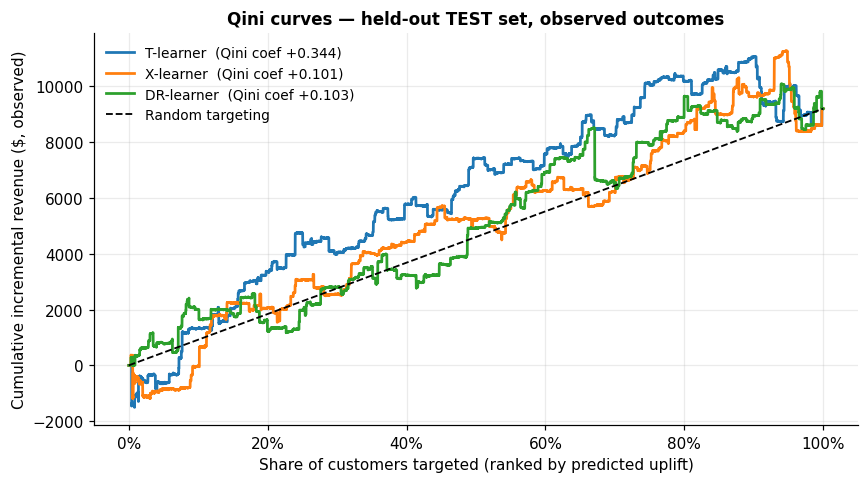

Selected learner: T-learner


In [14]:
def qini_curve(tau_hat, y, t):
    """Observed-outcome Qini. Returns (depth, qini, qini_coefficient)."""
    o = np.argsort(-tau_hat)
    ys, ts = y[o], t[o]
    k = np.arange(1, len(y) + 1)
    n_t, n_c = np.cumsum(ts), np.cumsum(1 - ts)
    s_t, s_c = np.cumsum(ys * ts), np.cumsum(ys * (1 - ts))
    ok = (n_t > 0) & (n_c > 0)
    uplift = np.zeros(len(y))
    uplift[ok] = s_t[ok] / n_t[ok] - s_c[ok] / n_c[ok]
    q = uplift * k
    depth = k / len(y)
    rand = depth * q[-1]                      # random-targeting diagonal
    area = lambda v: np.sum((v[1:] + v[:-1]) / 2 * np.diff(depth))
    coef = area(q - rand) / abs(area(rand)) if q[-1] != 0 else np.nan
    return depth, q, coef


fig, ax = plt.subplots()
qini_scores = {}
for name, tau in cate.items():
    d, q, coef = qini_curve(tau, y_te, t_te)
    qini_scores[name] = coef
    ax.plot(d, q, lw=1.8, label=f"{name}  (Qini coef {coef:+.3f})")
_, q_ref, _ = qini_curve(np.zeros(len(y_te)), y_te, t_te)
ax.plot([0, 1], [0, q_ref[-1]], "k--", lw=1.2, label="Random targeting")
ax.set_xlabel("Share of customers targeted (ranked by predicted uplift)")
ax.set_ylabel("Cumulative incremental revenue ($, observed)")
ax.set_title("Qini curves — held-out TEST set, observed outcomes")
ax.xaxis.set_major_formatter(PercentFormatter(1.0))
ax.legend(frameon=False, fontsize=9)
plt.tight_layout(); plt.show()

best = max(qini_scores, key=qini_scores.get)
tau_best = cate[best]
print(f"Selected learner: {best}")

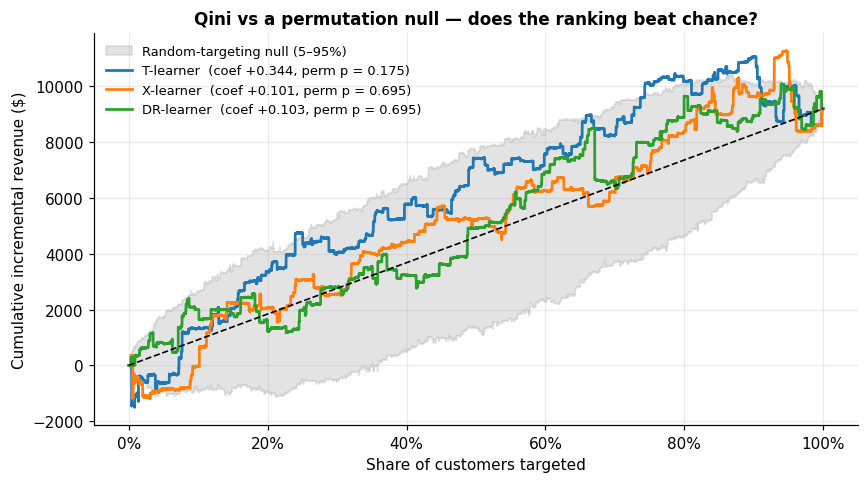

A curve inside the grey band is indistinguishable from random targeting.


In [15]:
# 9a-ii. Is the Qini curve better than chance? Permutation null band.
def qini_null(y, t, n_perm=200, seed=SEED):
    rs = np.random.default_rng(seed)
    curves, coefs = [], []
    for _ in range(n_perm):
        _, q, c = qini_curve(rs.normal(size=len(y)), y, t)
        curves.append(q); coefs.append(c)
    return np.vstack(curves), np.asarray(coefs)

null_curves, null_coefs = qini_null(y_te, t_te, n_perm=200)
lo_band = np.nanpercentile(null_curves, 5, axis=0)
hi_band = np.nanpercentile(null_curves, 95, axis=0)

fig, ax = plt.subplots()
depth = np.arange(1, len(y_te) + 1) / len(y_te)
ax.fill_between(depth, lo_band, hi_band, alpha=0.22, color="grey",
                label="Random-targeting null (5–95%)")
for name, tau in cate.items():
    d, q, coef = qini_curve(tau, y_te, t_te)
    pval = (np.abs(null_coefs) >= abs(coef)).mean()
    ax.plot(d, q, lw=1.8, label=f"{name}  (coef {coef:+.3f}, perm p = {pval:.3f})")
ax.plot([0, 1], [0, null_curves[0][-1]], "k--", lw=1.1)
ax.set_xlabel("Share of customers targeted"); ax.set_ylabel("Cumulative incremental revenue ($)")
ax.set_title("Qini vs a permutation null — does the ranking beat chance?")
ax.xaxis.set_major_formatter(PercentFormatter(1.0))
ax.legend(frameon=False, fontsize=8.5)
plt.tight_layout(); plt.show()

print("A curve inside the grey band is indistinguishable from random targeting.")

,quintile,n,predicted,observed_dim,dim_se,ci_lo,ci_hi,aipw,aipw_se
0,1,3853,0.1859,-0.2481,0.4925,-1.2138,0.7176,-0.2659,0.4936
1,2,3913,0.5801,0.7752,0.3343,0.1198,1.4306,0.7743,0.3339
2,3,3779,0.6865,0.3612,0.3195,-0.2653,0.9877,0.3626,0.3194
3,4,3872,0.8074,0.6684,0.3736,-0.0641,1.4009,0.6703,0.3737
4,5,3783,1.1994,0.8554,0.5944,-0.3101,2.0208,0.8494,0.5977


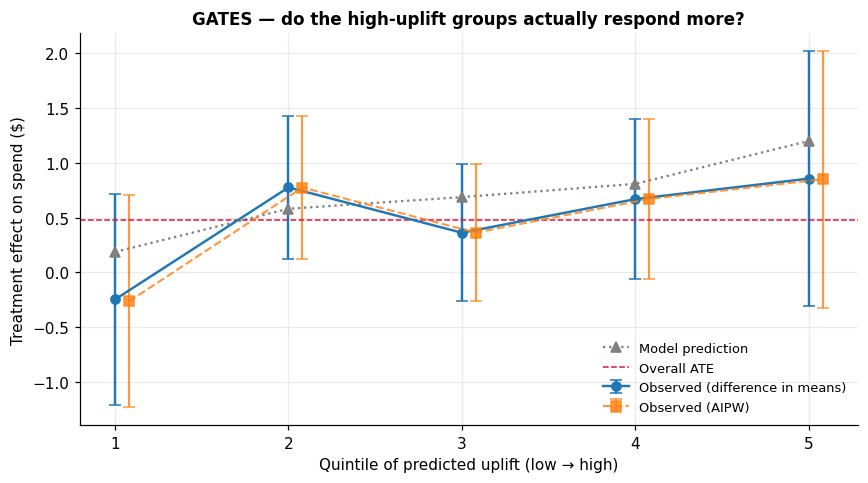

In [16]:
# 9b. GATES — effect estimated inside each predicted-uplift quintile.
def gates(tau_hat, y, t, gamma, n_groups=5):
    grp = pd.qcut(tau_hat, n_groups, labels=False, duplicates="drop")
    out = []
    for g in np.unique(grp):
        m = grp == g
        e, s, lo, hi, _ = diff_in_means(y[m], t[m])
        gm = gamma[m]
        out.append(dict(quintile=int(g) + 1, n=int(m.sum()),
                        predicted=tau_hat[m].mean(), observed_dim=e, dim_se=s,
                        ci_lo=lo, ci_hi=hi,
                        aipw=gm.mean(), aipw_se=gm.std(ddof=1) / np.sqrt(len(gm))))
    return pd.DataFrame(out)

gt = gates(tau_best, y_te, t_te, gamma_te)
display(gt)

fig, ax = plt.subplots()
ax.errorbar(gt["quintile"], gt["observed_dim"], yerr=1.96 * gt["dim_se"],
            fmt="o-", capsize=4, lw=1.6, label="Observed (difference in means)")
ax.errorbar(gt["quintile"] + 0.08, gt["aipw"], yerr=1.96 * gt["aipw_se"],
            fmt="s--", capsize=4, lw=1.4, alpha=0.8, label="Observed (AIPW)")
ax.plot(gt["quintile"], gt["predicted"], "^:", color="grey", label="Model prediction")
ax.axhline(gamma_te.mean(), color="crimson", ls="--", lw=1, label="Overall ATE")
ax.set_xticks(gt["quintile"])
ax.set_xlabel("Quintile of predicted uplift (low → high)")
ax.set_ylabel("Treatment effect on spend ($)")
ax.set_title("GATES — do the high-uplift groups actually respond more?")
ax.legend(frameon=False, fontsize=8.5)
plt.tight_layout(); plt.show()

In [17]:
# 9d. How much data would detecting this heterogeneity require?
# A null HTE result is only interpretable alongside the power to find one.

top, bot = gt.iloc[-1], gt.iloc[0]
spread = top["aipw"] - bot["aipw"]
se_spread = np.sqrt(top["aipw_se"] ** 2 + bot["aipw_se"] ** 2)
z80 = st.norm.ppf(0.975) + st.norm.ppf(0.80)

mde_spread = z80 * se_spread                       # detectable top-vs-bottom gap at current n
n_mult = (z80 * se_spread / spread) ** 2 if spread > 0 else np.nan

print("Heterogeneity power — top vs bottom CATE quintile")
print(f"  observed spread        : ${spread:+.4f}  (SE {se_spread:.4f}, "
      f"t = {spread / se_spread:.2f})")
print(f"  detectable spread @80% : ${mde_spread:.4f} at the current n")
print(f"  -> this experiment can only resolve heterogeneity roughly "
      f"{mde_spread / abs(gamma_te.mean()):.1f}x larger than the ATE itself\n")

if np.isfinite(n_mult):
    print(f"  sample multiplier for 80% power : {n_mult:.1f}x")
    print(f"  i.e. ~{n_mult * len(df):,.0f} customers "
          f"(vs {len(df):,} actual)")
print("\nInterpretation: the experiment is well powered for the ATE (section 4) and")
print("badly underpowered for the CATE. That is the norm — effect heterogeneity is a")
print("second-order quantity and typically needs an order of magnitude more data.")

Heterogeneity power — top vs bottom CATE quintile
  observed spread        : $+1.1153  (SE 0.7752, t = 1.44)
  detectable spread @80% : $2.1717 at the current n
  -> this experiment can only resolve heterogeneity roughly 4.5x larger than the ATE itself

  sample multiplier for 80% power : 3.8x
  i.e. ~242,664 customers (vs 64,000 actual)

Interpretation: the experiment is well powered for the ATE (section 4) and
badly underpowered for the CATE. That is the norm — effect heterogeneity is a
second-order quantity and typically needs an order of magnitude more data.


In [18]:
# 9c. Best Linear Predictor calibration test.
def blp_test(tau_hat, gamma):
    xc = tau_hat - tau_hat.mean()
    fit = sm.OLS(gamma, np.column_stack([np.ones(len(gamma)), xc])).fit(cov_type="HC3")
    ci = fit.conf_int()
    return pd.Series({"ate_beta0": fit.params[0], "ate_se": fit.bse[0],
                      "calibration_beta1": fit.params[1], "beta1_se": fit.bse[1],
                      "beta1_ci_lo": ci[1][0], "beta1_ci_hi": ci[1][1],
                      "p_beta1": fit.pvalues[1]})

blp = pd.DataFrame({name: blp_test(tau, gamma_te) for name, tau in cate.items()}).T
display(blp)
for name, r in blp.iterrows():
    lo, hi = r["beta1_ci_lo"], r["beta1_ci_hi"]
    detects = lo > 0
    calibrated = lo <= 1 <= hi
    verdict = ("detects real heterogeneity" if detects else
               "shows NO detectable heterogeneity (CI on beta1 includes 0)")
    scale = " and is correctly scaled" if (detects and calibrated) else ""
    width = hi - lo
    note = "  [CI is too wide to be informative]" if width > 2 else ""
    print(f"{name:<11}: beta1 = {r['calibration_beta1']:+.3f} "
          f"[{lo:+.3f}, {hi:+.3f}] -> {verdict}{scale}{note}")

,ate_beta0,ate_se,calibration_beta1,beta1_se,beta1_ci_lo,beta1_ci_hi,p_beta1
T-learner,0.4783,0.1949,-0.1378,1.0790,-2.2527,1.9770,0.8984
X-learner,0.4783,0.1948,-0.0413,1.5967,-3.1707,3.0881,0.9793
DR-learner,0.4783,0.1948,0.2278,0.5417,-0.8339,1.2896,0.6741


T-learner  : beta1 = -0.138 [-2.253, +1.977] -> shows NO detectable heterogeneity (CI on beta1 includes 0)  [CI is too wide to be informative]
X-learner  : beta1 = -0.041 [-3.171, +3.088] -> shows NO detectable heterogeneity (CI on beta1 includes 0)  [CI is too wide to be informative]
DR-learner : beta1 = +0.228 [-0.834, +1.290] -> shows NO detectable heterogeneity (CI on beta1 includes 0)  [CI is too wide to be informative]


## 10. From CATE to a policy — and what it is actually worth

A targeting rule is a policy $\pi: X \to \{0, 1\}$. Its value, net of the per-e-mail cost $c$, is estimated
**without** using the model's predicted uplift as the payoff:

$$\hat V(\pi) = \frac{1}{n}\sum_{i \in \text{TEST}} \pi(X_i)\,(\Gamma_i - c)$$

Because $E[\Gamma \mid X] = \tau(X)$, this is unbiased for the true policy value, and the per-customer terms
form an influence function — so it comes with a standard error, and two policies can be compared with a
*paired* SE that accounts for the customers they treat in common.

Three policies compared: treat nobody, treat everybody, and treat where $\hat\tau(x) > c$.

In [19]:
COST = 0.10

def policy_value(pi, gamma, cost):
    v = pi * (gamma - cost)
    return v, v.mean(), v.std(ddof=1) / np.sqrt(len(v))

policies = {
    "Treat nobody": np.zeros(len(te_i)),
    "Blanket (treat everybody)": np.ones(len(te_i)),
    f"Targeted: τ̂ > ${COST:.2f}": (tau_best > COST).astype(float),
}

res, infl = [], {}
for name, pi in policies.items():
    v, m, s = policy_value(pi, gamma_te, COST)
    infl[name] = v
    res.append(dict(policy=name, treated_share=pi.mean(), value_per_customer=m, se=s,
                    ci_lo=m - 1.96 * s, ci_hi=m + 1.96 * s,
                    value_at_64k_customers=m * 64000))
pv = pd.DataFrame(res)
display(pv)

a, b = f"Targeted: τ̂ > ${COST:.2f}", "Blanket (treat everybody)"
d = infl[a] - infl[b]
print(f"Targeted − Blanket = ${d.mean():+.4f} per customer "
      f"(paired SE {d.std(ddof=1)/np.sqrt(len(d)):.4f}, "
      f"95% CI [{d.mean()-1.96*d.std(ddof=1)/np.sqrt(len(d)):+.4f}, "
      f"{d.mean()+1.96*d.std(ddof=1)/np.sqrt(len(d)):+.4f}])")
lo_d = d.mean() - 1.96 * d.std(ddof=1) / np.sqrt(len(d))
print("Verdict:", "targeting beats blanket at 95% confidence." if lo_d > 0 else
      "the interval spans zero — targeting is NOT demonstrably better than mailing "
      "everyone. That is a decision-relevant finding, not a failed project: it says the "
      "heterogeneity here is too small to monetise at this sample size.")

,policy,treated_share,value_per_customer,se,ci_lo,ci_hi,value_at_64k_customers
0,Treat nobody,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
1,Blanket (treat everybody),1.0000,0.3783,0.1948,-0.0035,0.7601,"24,213.4748"
2,Targeted: τ̂ > $0.10,0.9592,0.4288,0.1869,0.0625,0.7951,"27,444.5096"


Targeted − Blanket = $+0.0505 per customer (paired SE 0.0549, 95% CI [-0.0571, +0.1581])
Verdict: the interval spans zero — targeting is NOT demonstrably better than mailing everyone. That is a decision-relevant finding, not a failed project: it says the heterogeneity here is too small to monetise at this sample size.


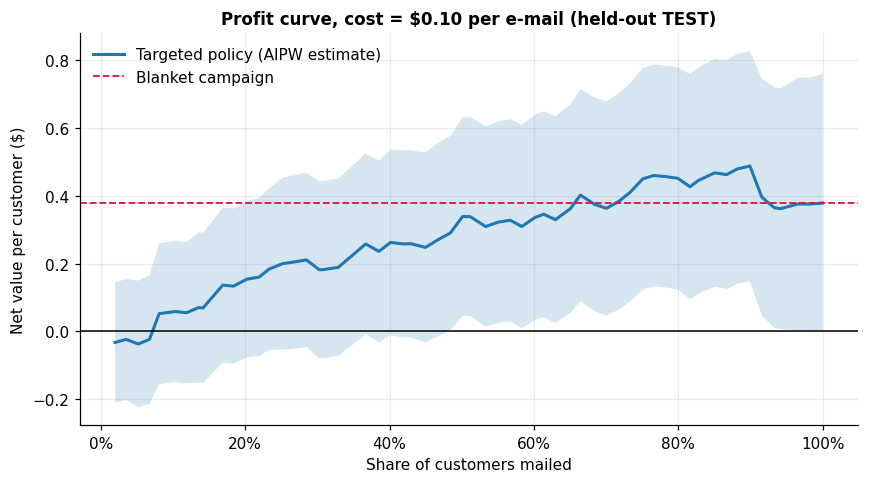

In [20]:
# Value as a function of the targeting threshold, with uncertainty band.
ths = np.quantile(tau_best, np.linspace(0.0, 0.98, 60))
vals, ses, shares = [], [], []
for th in ths:
    pi = (tau_best > th).astype(float)
    _, m, s = policy_value(pi, gamma_te, COST)
    vals.append(m); ses.append(s); shares.append(pi.mean())
vals, ses, shares = map(np.asarray, (vals, ses, shares))

fig, ax = plt.subplots()
ax.plot(shares, vals, lw=2, label="Targeted policy (AIPW estimate)")
ax.fill_between(shares, vals - 1.96 * ses, vals + 1.96 * ses, alpha=0.18)
ax.axhline(pv.loc[1, "value_per_customer"], color="crimson", ls="--", lw=1.2,
           label="Blanket campaign")
ax.axhline(0, color="black", lw=1)
ax.set_xlabel("Share of customers mailed")
ax.set_ylabel("Net value per customer ($)")
ax.set_title(f"Profit curve, cost = ${COST:.2f} per e-mail (held-out TEST)")
ax.xaxis.set_major_formatter(PercentFormatter(1.0))
ax.legend(frameon=False)
plt.tight_layout(); plt.show()

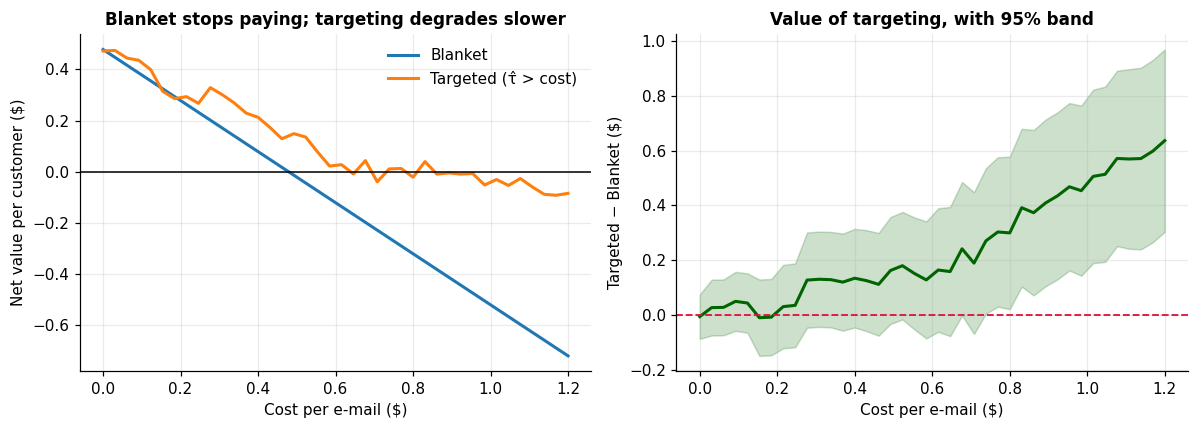

Blanket campaign turns unprofitable above $0.49 per send.
Targeting is significantly better than blanket for costs above $0.74.
At a realistic e-mail cost (cents), blanket is the correct decision here —
targeting only earns its keep once sends are expensive or capacity-constrained.


In [21]:
# 10a-ii. Does the cost of a send change the answer?
# pi_c(x) = 1{tau_hat(x) > c} is the optimal rule at cost c -- no threshold tuning.

costs = np.linspace(0.0, 1.2, 40)
rows = []
for c in costs:
    pi = (tau_best > c).astype(float)
    v_t = pi * (gamma_te - c)
    v_b = gamma_te - c
    diff = v_t - v_b
    rows.append(dict(cost=c, share=pi.mean(),
                     targeted=v_t.mean(), blanket=v_b.mean(),
                     gap=diff.mean(), gap_se=diff.std(ddof=1) / np.sqrt(len(diff))))
cs = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(cs["cost"], cs["blanket"], lw=2, label="Blanket")
axes[0].plot(cs["cost"], cs["targeted"], lw=2, label="Targeted (τ̂ > cost)")
axes[0].axhline(0, color="black", lw=1)
axes[0].set_xlabel("Cost per e-mail ($)"); axes[0].set_ylabel("Net value per customer ($)")
axes[0].set_title("Blanket stops paying; targeting degrades slower")
axes[0].legend(frameon=False)

axes[1].plot(cs["cost"], cs["gap"], lw=2, color="darkgreen")
axes[1].fill_between(cs["cost"], cs["gap"] - 1.96 * cs["gap_se"],
                     cs["gap"] + 1.96 * cs["gap_se"], alpha=0.2, color="darkgreen")
axes[1].axhline(0, color="crimson", ls="--", lw=1.2)
axes[1].set_xlabel("Cost per e-mail ($)"); axes[1].set_ylabel("Targeted − Blanket ($)")
axes[1].set_title("Value of targeting, with 95% band")
plt.tight_layout(); plt.show()

breakeven = cs.loc[cs["blanket"] < 0, "cost"].min()
sig_cost = cs.loc[cs["gap"] - 1.96 * cs["gap_se"] > 0, "cost"]
print(f"Blanket campaign turns unprofitable above ${breakeven:.2f} per send.")
print(f"Targeting is significantly better than blanket for costs "
      f"{'above $%.2f' % sig_cost.min() if len(sig_cost) else 'at NO cost level tested'}.")
print("At a realistic e-mail cost (cents), blanket is the correct decision here —")
print("targeting only earns its keep once sends are expensive or capacity-constrained.")

### 10b. Multi-arm policy: *which* e-mail, not just *whether*

Pooling both e-mails throws away the most interesting structure in the experiment. With three arms the
policy becomes $\pi: X \to \{\text{none}, \text{mens}, \text{womens}\}$, and an AIPW score is built per arm:

$$\Gamma^{(a)}_i = \hat\mu_a(X_i) - \hat\mu_0(X_i) + \frac{\mathbb 1\{A_i=a\}}{p_a}\big(Y_i - \hat\mu_a\big) - \frac{\mathbb 1\{A_i=0\}}{p_0}\big(Y_i - \hat\mu_0\big)$$

The learned policy assigns $\arg\max_a (\hat\tau_a(x) - c)$, falling back to "none" when no arm clears cost.
Its value is again estimated from observed outcomes, never from predictions.

In [22]:
ARMS = ["No E-Mail", "Mens E-Mail", "Womens E-Mail"]
a_tr, a_te = arm_all[tr_i], arm_all[te_i]

mu_a = {}
tau_a = {}
for arm in ARMS:
    m = make_learner().fit(X_tr[a_tr == arm], y_tr[a_tr == arm])
    mu_a[arm] = m.predict(X_te)
for arm in ARMS[1:]:
    tau_a[arm] = mu_a[arm] - mu_a["No E-Mail"]

p_ctrl = (a_te == "No E-Mail").mean()
gamma_a = {}
for arm in ARMS[1:]:
    pa = (a_te == arm).mean()
    gamma_a[arm] = (mu_a[arm] - mu_a["No E-Mail"]
                    + (a_te == arm) / pa * (y_te - mu_a[arm])
                    - (a_te == "No E-Mail") / p_ctrl * (y_te - mu_a["No E-Mail"]))

stack = np.column_stack([np.zeros(len(te_i))] + [tau_a[a] - COST for a in ARMS[1:]])
choice = stack.argmax(axis=1)                       # 0 = none, 1 = mens, 2 = womens
gain = np.zeros(len(te_i))
for j, arm in enumerate(ARMS[1:], start=1):
    m = choice == j
    gain[m] = gamma_a[arm][m] - COST

print("Learned multi-arm policy — allocation on TEST")
for j, lbl in enumerate(["No e-mail", "Mens e-mail", "Womens e-mail"]):
    print(f"  {lbl:<15} {(choice == j).mean():6.1%}")
print(f"\nPolicy value = ${gain.mean():+.4f} per customer "
      f"(SE {gain.std(ddof=1)/np.sqrt(len(gain)):.4f})")

best_single = max(ARMS[1:], key=lambda a: (gamma_a[a] - COST).mean())
bs = gamma_a[best_single] - COST
diff = gain - bs
print(f"Best single-arm blanket ({best_single}): ${bs.mean():+.4f} per customer")
print(f"Multi-arm targeting − best blanket = ${diff.mean():+.4f} "
      f"(paired SE {diff.std(ddof=1)/np.sqrt(len(diff)):.4f})")

Learned multi-arm policy — allocation on TEST
  No e-mail         2.7%
  Mens e-mail      76.5%
  Womens e-mail    20.8%

Policy value = $+0.5598 per customer (SE 0.2449)
Best single-arm blanket (Mens E-Mail): $+0.3979 per customer
Multi-arm targeting − best blanket = $+0.1619 (paired SE 0.1593)


### 10c. Rank on engagement, evaluate on revenue

The heterogeneity analysis above fails for a mechanical reason, not a conceptual one: `spend` is 99.1%
zeros with an SD of $11.59, so the CATE signal is buried under outcome noise that has nothing to do with
the treatment. `visit` is the same underlying behaviour measured without that noise — a 10.6% base rate,
variance ~0.09 instead of ~134.

So: **estimate the CATE on the low-variance engagement proxy, then evaluate the resulting policy on the
revenue scale using the revenue AIPW scores.** The ranking is allowed to come from anywhere; the scoring
is what has to be honest. This is standard practice — surrogate or proxy metrics for targeting, the true
metric for the decision.

The proxy is only useful if incremental visits convert like average visits. Section 5b supports that
(95% of the revenue effect ran through conversion, with essentially flat AOV), but it is an assumption
and is flagged as one.

,ate_beta0,ate_se,calibration_beta1,beta1_se,beta1_ci_lo,beta1_ci_hi,p_beta1
T-learner,0.0647,0.0050,0.7379,0.1982,0.3494,1.1265,0.0002
X-learner,0.0647,0.0050,1.5702,0.4013,0.7837,2.3567,0.0001
DR-learner,0.0647,0.0050,1.8810,0.4953,0.9103,2.8518,0.0001


T-learner  : beta1 = +0.738 [+0.349, +1.126] -> HETEROGENEITY DETECTED
X-learner  : beta1 = +1.570 [+0.784, +2.357] -> HETEROGENEITY DETECTED
DR-learner : beta1 = +1.881 [+0.910, +2.852] -> HETEROGENEITY DETECTED

Selected engagement learner: X-learner


,quintile,n,predicted,observed_dim,ci_lo,ci_hi
0,1,3845,0.0423,0.0314,0.0085,0.0543
1,2,3838,0.0509,0.0642,0.0428,0.0856
2,3,3842,0.0597,0.0562,0.0344,0.0779
3,4,3849,0.0675,0.0704,0.0495,0.0913
4,5,3826,0.0778,0.0988,0.0757,0.1219


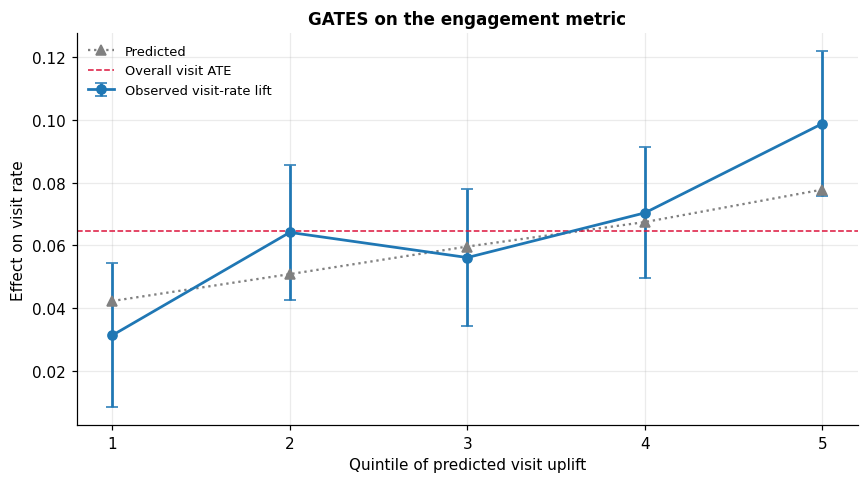

In [23]:
# CATE on the engagement proxy, policy evaluated on revenue.
y_vis = df["y_visit"].to_numpy(float)
y_vis_tr = y_vis[tr_i]
y_vis_te = y_vis[te_i]

mu0_v = make_learner().fit(X_tr[t_tr == 0], y_vis_tr[t_tr == 0]).predict(X_te)
mu1_v = make_learner().fit(X_tr[t_tr == 1], y_vis_tr[t_tr == 1]).predict(X_te)
gamma_vis = aipw_gamma(y_vis_te, t_te, mu0_v, mu1_v)

cate_vis = {}
for name, fitter in [("T-learner", fit_t_learner), ("X-learner", fit_x_learner),
                     ("DR-learner", fit_dr_learner)]:
    cate_vis[name] = fitter(X_tr, t_tr, y_vis_tr)(X_te)

blp_vis = pd.DataFrame({n: blp_test(t_, gamma_vis) for n, t_ in cate_vis.items()}).T
display(blp_vis)

for name, r in blp_vis.iterrows():
    lo, hi = r["beta1_ci_lo"], r["beta1_ci_hi"]
    print(f"{name:<11}: beta1 = {r['calibration_beta1']:+.3f} [{lo:+.3f}, {hi:+.3f}] -> "
          f"{'HETEROGENEITY DETECTED' if lo > 0 else 'not detected'}")

best_vis = (blp_vis["calibration_beta1"] / blp_vis["beta1_se"]).idxmax()
tau_vis = cate_vis[best_vis]
print(f"\nSelected engagement learner: {best_vis}")

gt_vis = gates(tau_vis, y_vis_te, t_te, gamma_vis)
display(gt_vis[["quintile", "n", "predicted", "observed_dim", "ci_lo", "ci_hi"]])

fig, ax = plt.subplots()
ax.errorbar(gt_vis["quintile"], gt_vis["observed_dim"], yerr=1.96 * gt_vis["dim_se"],
            fmt="o-", capsize=4, lw=1.8, label="Observed visit-rate lift")
ax.plot(gt_vis["quintile"], gt_vis["predicted"], "^:", color="grey", label="Predicted")
ax.axhline(gamma_vis.mean(), color="crimson", ls="--", lw=1, label="Overall visit ATE")
ax.set_xticks(gt_vis["quintile"])
ax.set_xlabel("Quintile of predicted visit uplift"); ax.set_ylabel("Effect on visit rate")
ax.set_title("GATES on the engagement metric")
ax.legend(frameon=False, fontsize=8.5)
plt.tight_layout(); plt.show()

In [24]:
# Translate engagement uplift to money, then score the policy on REVENUE.
ctrl_te = t_te == 0
value_per_visit = y_te[ctrl_te & (y_vis_te == 1)].mean()
print(f"Revenue per visit (control arm) = ${value_per_visit:.2f}")
print("Assumption: marginal visits monetise like average visits (see 5b).\n")

tau_rev = tau_vis * value_per_visit                 # engagement CATE -> dollars
pi_proxy = (tau_rev > COST).astype(float)

comparison = {
    "Blanket": np.ones(len(te_i)),
    f"Targeted on spend-CATE": (tau_best > COST).astype(float),
    f"Targeted on visit-CATE": pi_proxy,
}
rows, infl2 = [], {}
for name, pi in comparison.items():
    v = pi * (gamma_te - COST)                      # scored on REVENUE, always
    infl2[name] = v
    rows.append(dict(policy=name, treated_share=pi.mean(), value=v.mean(),
                     se=v.std(ddof=1) / np.sqrt(len(v))))
cmp_df = pd.DataFrame(rows)
cmp_df["ci_lo"] = cmp_df["value"] - 1.96 * cmp_df["se"]
cmp_df["ci_hi"] = cmp_df["value"] + 1.96 * cmp_df["se"]
display(cmp_df)

d2 = infl2["Targeted on visit-CATE"] - infl2["Blanket"]
se2 = d2.std(ddof=1) / np.sqrt(len(d2))
print(f"Proxy-targeted − Blanket = ${d2.mean():+.4f} per customer "
      f"(paired SE {se2:.4f}, 95% CI [{d2.mean()-1.96*se2:+.4f}, {d2.mean()+1.96*se2:+.4f}])")
print("Ranking quality and revenue significance are separate questions: the proxy can")
print("rank customers well while the revenue gain stays inside the noise.")

Revenue per visit (control arm) = $7.21
Assumption: marginal visits monetise like average visits (see 5b).



,policy,treated_share,value,se,ci_lo,ci_hi
0,Blanket,1.0000,0.3783,0.1948,-0.0035,0.7601
1,Targeted on spend-CATE,0.9592,0.4288,0.1869,0.0625,0.7951
2,Targeted on visit-CATE,0.9972,0.3646,0.1943,-0.0163,0.7456


Proxy-targeted − Blanket = $-0.0137 per customer (paired SE 0.0131, 95% CI [-0.0394, +0.0120])
Ranking quality and revenue significance are separate questions: the proxy can
rank customers well while the revenue gain stays inside the noise.


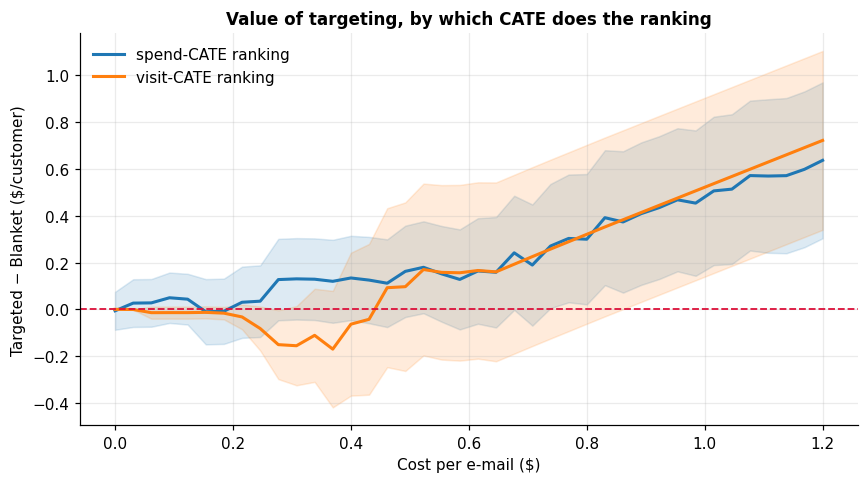

visit-CATE targeting beats blanket for costs above $0.86.


In [25]:
# 10a-iii. Re-run the cost sweep with the ranking that actually works.
tau_rev_hat = tau_vis * value_per_visit
rows = []
for c in costs:
    pi = (tau_rev_hat > c).astype(float)
    d = pi * (gamma_te - c) - (gamma_te - c)
    rows.append(dict(cost=c, share=pi.mean(), gap=d.mean(),
                     gap_se=d.std(ddof=1) / np.sqrt(len(d))))
cs2 = pd.DataFrame(rows)

fig, ax = plt.subplots()
for lbl, frame in [("spend-CATE ranking", cs), ("visit-CATE ranking", cs2)]:
    ln, = ax.plot(frame["cost"], frame["gap"], lw=2, label=lbl)
    ax.fill_between(frame["cost"], frame["gap"] - 1.96 * frame["gap_se"],
                    frame["gap"] + 1.96 * frame["gap_se"], alpha=0.15, color=ln.get_color())
ax.axhline(0, color="crimson", ls="--", lw=1.2)
ax.set_xlabel("Cost per e-mail ($)"); ax.set_ylabel("Targeted − Blanket ($/customer)")
ax.set_title("Value of targeting, by which CATE does the ranking")
ax.legend(frameon=False)
plt.tight_layout(); plt.show()

win = cs2.loc[cs2["gap"] - 1.96 * cs2["gap_se"] > 0, "cost"]
print(f"visit-CATE targeting beats blanket for costs above "
      f"${win.min():.2f}." if len(win) else
      "visit-CATE targeting never separates from blanket at 95% across tested costs.")

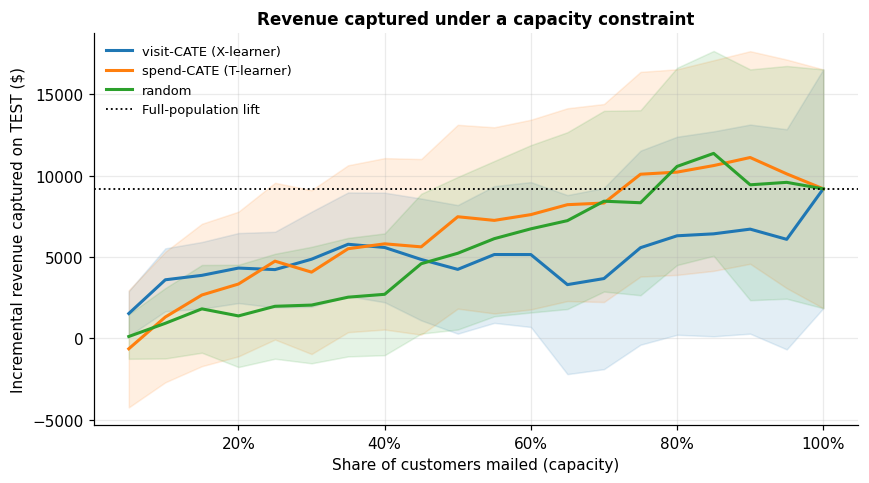

Total incremental revenue available on TEST: $9,184
At 20% capacity, revenue captured:
  visit-CATE (X-learner)       $    4,319   ( 47.0% of total)
  spend-CATE (T-learner)       $    3,339   ( 36.4% of total)
  random                       $    1,381   ( 15.0% of total)

A ranker beating the 20% diagonal is delivering real targeting value;
the gap over `random` is the model's contribution, in dollars.


In [26]:
# 10d. The binding constraint in marketing is capacity, not cost.
# "We can mail k% of the base — who?" Revenue captured is scored on AIPW revenue
# scores, so the ranking may come from engagement but the payoff never does.

rankers = {
    f"visit-CATE ({best_vis})": tau_vis,
    f"spend-CATE ({best})": tau_best,
    "random": np.random.default_rng(SEED).normal(size=len(te_i)),
}
ks = np.linspace(0.05, 1.0, 20)

fig, ax = plt.subplots()
capture = {}
for name, r in rankers.items():
    vals, ses = [], []
    for k in ks:
        pi = (r >= np.quantile(r, 1 - k)).astype(float)
        v = pi * gamma_te
        vals.append(v.mean() * len(te_i)); ses.append(v.std(ddof=1) * np.sqrt(len(te_i)))
    vals, ses = np.asarray(vals), np.asarray(ses)
    capture[name] = vals
    ln, = ax.plot(ks, vals, lw=2, label=name)
    ax.fill_between(ks, vals - 1.96 * ses, vals + 1.96 * ses, alpha=0.12,
                    color=ln.get_color())
ax.axhline(gamma_te.sum(), color="black", ls=":", lw=1.2, label="Full-population lift")
ax.set_xlabel("Share of customers mailed (capacity)")
ax.set_ylabel("Incremental revenue captured on TEST ($)")
ax.set_title("Revenue captured under a capacity constraint")
ax.xaxis.set_major_formatter(PercentFormatter(1.0))
ax.legend(frameon=False, fontsize=8.5)
plt.tight_layout(); plt.show()

total = gamma_te.sum()
k20 = np.argmin(np.abs(ks - 0.20))
print(f"Total incremental revenue available on TEST: ${total:,.0f}")
print(f"At 20% capacity, revenue captured:")
for name, vals in capture.items():
    share = f"{vals[k20] / total:6.1%}" if abs(total) > 1e-6 else "   n/a"
    print(f"  {name:<28} ${vals[k20]:>9,.0f}   ({share} of total)")
print("\nA ranker beating the 20% diagonal is delivering real targeting value;")
print("the gap over `random` is the model's contribution, in dollars.")

## 11. Appendix — why continuous monitoring breaks fixed-horizon tests

Fixed-horizon p-values assume you look **once**. Dashboards invite looking daily, and each look is another
chance to cross the threshold. Below: 4,000 simulated A/A tests (no true effect) with 10 interim looks,
stopping at the first p < 0.05.

The fix used in industry is either an alpha-spending boundary (O'Brien–Fleming, Pocock) or an always-valid
sequential test (mSPRT, confidence sequences). A Pocock-style constant boundary is calibrated by simulation
here to restore the 5% family-wise rate.

Look once, at the end        : false positive rate 5.1%  (nominal 5%)
Peek 10× at |z| > 1.96      : false positive rate 18.6%
Pocock-style boundary |z| > 2.54 : false positive rate 5.0%


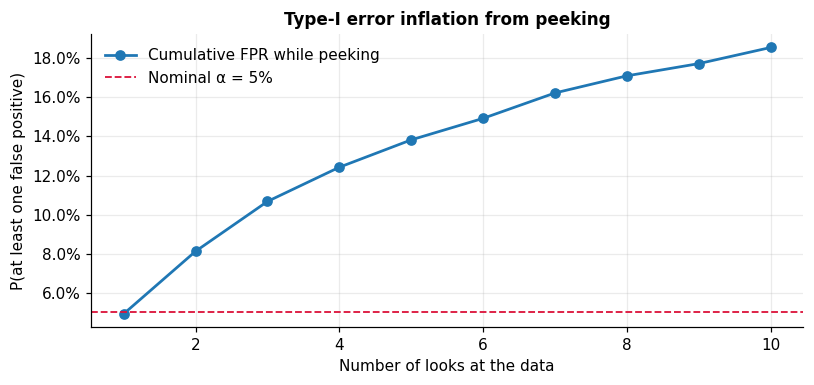

In [27]:
N_SIM, N_LOOKS, N_PER_ARM = 4000, 10, 2000
sim = np.random.default_rng(7)
sizes = np.linspace(N_PER_ARM / N_LOOKS, N_PER_ARM, N_LOOKS).astype(int)

za = sim.normal(size=(N_SIM, N_PER_ARM))
zb = sim.normal(size=(N_SIM, N_PER_ARM))
ca, cb = np.cumsum(za, 1), np.cumsum(zb, 1)
k = sizes - 1
zstat = (ca[:, k] / sizes - cb[:, k] / sizes) / np.sqrt(2 / sizes)
peek_max = np.abs(zstat).max(axis=1)

fixed_fpr = (np.abs(zstat[:, -1]) > 1.96).mean()
peek_fpr = (peek_max > 1.96).mean()
pocock = np.quantile(peek_max, 0.95)
corrected = (peek_max > pocock).mean()

print(f"Look once, at the end        : false positive rate {fixed_fpr:.1%}  (nominal 5%)")
print(f"Peek {N_LOOKS}× at |z| > 1.96      : false positive rate {peek_fpr:.1%}")
print(f"Pocock-style boundary |z| > {pocock:.2f} : false positive rate {corrected:.1%}")

fig, ax = plt.subplots(figsize=(7.5, 3.6))
cum = [(np.abs(zstat[:, :j + 1]) > 1.96).any(axis=1).mean() for j in range(N_LOOKS)]
ax.plot(range(1, N_LOOKS + 1), cum, "o-", lw=1.8, label="Cumulative FPR while peeking")
ax.axhline(0.05, color="crimson", ls="--", lw=1.2, label="Nominal α = 5%")
ax.set_xlabel("Number of looks at the data"); ax.set_ylabel("P(at least one false positive)")
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_title("Type-I error inflation from peeking")
ax.legend(frameon=False)
plt.tight_layout(); plt.show()

## 12. Limitations, and what production would require

**Of the experiment**

- *Two-week window.* Everything estimated here is a short-run effect. E-mail campaigns plausibly pull
  purchases forward rather than create them; distinguishing incremental revenue from cannibalised revenue
  needs a longer holdout and repeat-purchase tracking.
- *Novelty and fatigue.* A single send says nothing about the effect of a recurring programme. Long-run
  effects need a holdout group that stays untreated across many campaigns.
- *SUTVA.* Assumed here, and reasonable for e-mail. It would fail for anything with sharing, referral, or
  marketplace supply effects, where switchback or cluster randomisation is required.
- *Zero-inflation.* 99% of the outcome is zeros and the tail is heavy. The mean is the right business
  metric, but it is unstable; a capped/winsorised secondary metric is standard practice to keep a handful
  of large orders from driving the decision.

**Of the causal ML**

- CATE estimation is far more data-hungry than ATE estimation. The GATES intervals in §9 are wide relative
  to the effects, and that is the honest signal about how much heterogeneity this experiment can support.
- The learned policy is evaluated on held-out data, but the *threshold* was chosen by looking at that same
  held-out profit curve. A third split, or nested cross-fitting, would be needed before shipping.
- Any policy learned from an experiment is only valid over the covariate distribution the experiment
  covered. Deploying it shifts that distribution, so the policy degrades and must be re-randomised
  periodically — a permanent holdout arm is the cheapest insurance.

**What shipping this would involve**

The SQL becomes a dbt model; the cross-fitting pipeline becomes a scheduled job writing CATE scores to a
feature store; the policy threshold becomes a config value tied to actual send cost; and the whole thing
runs behind a 5% permanent holdout so the estimated uplift can be re-validated against reality every cycle.